# Regresi Linear

In [4]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error
)

## Data Preparation

In [5]:
# Data Preparation
df = pd.read_excel("../Data Final/Final_PM14.xlsx")

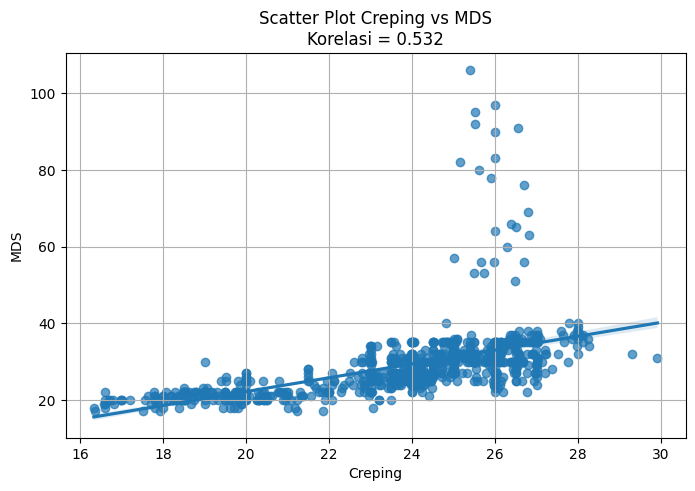

In [6]:
# Hitung korelasi Pearson
corr = df['Mean_Creping'].corr(df['MDS'])

# Plot
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Mean_Creping'],
    y=df['MDS'],
    scatter_kws={'alpha':0.7}
)

plt.title(f'Scatter Plot Creping vs MDS\nKorelasi = {corr:.3f}')
plt.xlabel('Creping')
plt.ylabel('MDS')

plt.grid(True)
plt.show()

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start_Time               906 non-null    datetime64[us]
 1   End_Time                 906 non-null    datetime64[us]
 2   Data_Count               906 non-null    int64         
 3   Mean_Creping             906 non-null    float64       
 4   Mean_Yankee Speed        906 non-null    float64       
 5   Mean_Pope Reel Speed     906 non-null    float64       
 6   Mean_Yankee Pressure     906 non-null    float64       
 7   Mean_Stock Flow          906 non-null    float64       
 8   Mean_Stock Consistency   906 non-null    float64       
 9   Mean_Flow Coating        906 non-null    float64       
 10  Mean_Flow Release        906 non-null    float64       
 11  Mean_Jet Wire Ratio      906 non-null    float64       
 12  Mean_Load KWH Refiner    906 non-null    float6

In [8]:
high_mds = (df['MDS'] > 50).sum()
print(high_mds)

24


In [9]:
# Data Selection
df = df[df['MDS'] <= 40]

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)


## Modelling Linear Regression

In [10]:
# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

In [ ]:
# Features -> Hasil OLS
selected_features = ['Mean_Yankee Pressure', 'Mean_Creping', '% NBKP', 'Mean_Jet Wire Ratio', 'GSM']

# X Variables
X = df[selected_features]

# Y Variables
target = 'MDS'
y = df[target]

In [13]:
# Centering
X_mean = X.mean() # simpan mean training
X_centered = X - X_mean
print("Mean Features", X_mean)

Mean Features Mean_Yankee Pressure     7.279805
Mean_Creping            22.542516
% NBKP                  17.161773
Mean_Jet Wire Ratio      0.942094
GSM                     12.747409
dtype: float64


In [14]:
# RIDGE REGRESSION
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_centered, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [15]:
# PREDIKSI
y_pred = ridge_model.predict(X_centered)

In [16]:
# EVALUASI MODEL
r2 = r2_score(y, y_pred)

rmse = np.sqrt(mean_squared_error(y, y_pred))

mape = mean_absolute_percentage_error(y,y_pred) * 100

print("\n===== EVALUASI MODEL =====")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")


===== EVALUASI MODEL =====
R²   : 0.7852
RMSE : 2.2052
MAPE : 6.34%


In [ ]:
# KOEFISIEN
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': ridge_model.coef_
})

print("\n===== KOEFISIEN RIDGE =====")
print(coef_df)

# INTERCEPT
print("\n===== INTERCEPT =====")
print(ridge_model.intercept_)


===== KOEFISIEN RIDGE =====
                Feature  Coefficient
0  Mean_Yankee Pressure     0.513585
1          Mean_Creping     0.864550
2                % NBKP     0.876502
3   Mean_Jet Wire Ratio    -0.382126
4                   GSM    -0.886777

===== INTERCEPT =====
25.401554404145077


### Residual Plot

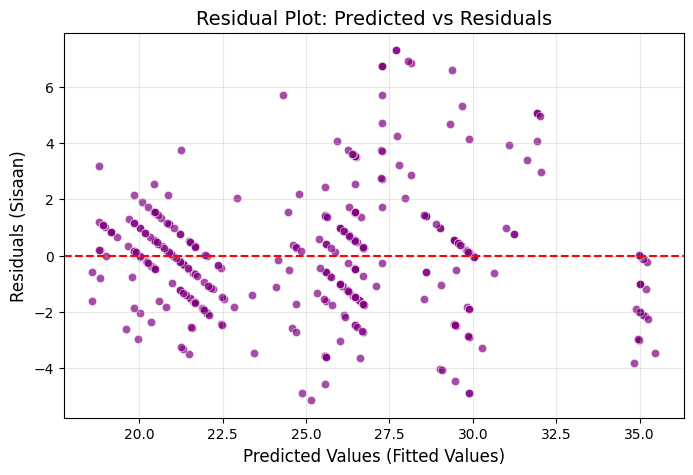

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Hitung prediksi dan residual (sisaan)
y_pred = ridge_model.predict(X_centered) 
residuals = y - y_pred

# 2. Membuat Plot Predicted vs Residuals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.title('Residual Plot: Predicted vs Residuals', fontsize=14)
plt.xlabel('Predicted Values (Fitted Values)', fontsize=12)
plt.ylabel('Residuals (Sisaan)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Import Model

In [ ]:
import joblib
import os

# Folder model
#os.makedirs("models/PM14/MDS", exist_ok=True)

# Simpan model
#joblib.dump(model_no_const, "models/PM14/MDS/model.pkl")

# Simpan fitur
#joblib.dump(features, "models/PM14/MDS/features.pkl")

print("Model berhasil disimpan!")

## Pemeriksaan Asumsi IIDN

### Independen (Autokorelasi)

In [28]:
from statsmodels.stats.stattools import durbin_watson
# Uji Durbin-Watson
DW = durbin_watson(residuals)
print("===== UJI INDEPENDENSI (DURBIN-WATSON) =====")
print(f"Nilai Durbin-Watson: {dw_status:.4f}")
print("Petunjuk Interpretasi:")
print("- Nilai dekat 2  : Tidak ada autokorelasi (Aman/Independen)")
print("- Nilai dekat 0  : Ada autokorelasi positif")
print("- Nilai dekat 4  : Ada autokorelasi negatif")

if DW > 1.5 and DW < 2.5:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 1.5:
    print('Terdapat autokorelasi positif.')
elif DW > 2.5:
    print('Terdapat autokorelasi negatif.')

===== UJI INDEPENDENSI (DURBIN-WATSON) =====
Nilai Durbin-Watson: 0.7986
Petunjuk Interpretasi:
- Nilai dekat 2  : Tidak ada autokorelasi (Aman/Independen)
- Nilai dekat 0  : Ada autokorelasi positif
- Nilai dekat 4  : Ada autokorelasi negatif
Terdapat autokorelasi positif.


### Indentik (Heterokesdastisitas)

In [24]:
from statsmodels.stats.diagnostic import het_breuschpagan
import pandas as pd
import statsmodels.api as sm

# Breusch-Pagan membutuhkan matriks eksogen (X) yang memiliki konstanta/intercept
X_with_const = sm.add_constant(X_centered)

# Jalankan uji
bp_test = het_breuschpagan(residuals, X_with_const)
labels = ['Lagrange Multiplier statistic', 'p-value', 'f-value', 'f p-value']

print("===== UJI HOMOSKEDASTISITAS (BREUSCH-PAGAN) =====")
for label, value in zip(labels, bp_test):
    print(f"{label:<30}: {value:.4f}")

if bp_test[1] > 0.05:
    print("\nKesimpulan: Homoskedastisitas Terpenuhi (Varians Bersifat Identik/Konstan)")
else:
    print("\nKesimpulan: Heteroskedastisitas Terdeteksi (Varians Tidak Identik)")

===== UJI HOMOSKEDASTISITAS (BREUSCH-PAGAN) =====
Lagrange Multiplier statistic : 34.6753
p-value                       : 0.0000
f-value                       : 7.5011
f p-value                     : 0.0000

Kesimpulan: Heteroskedastisitas Terdeteksi (Varians Tidak Identik)


Terjadi Heteroskedastisitas yang parah pada model. Varians dari residual terbukti secara empiris tidak konstan.

### Normalitas

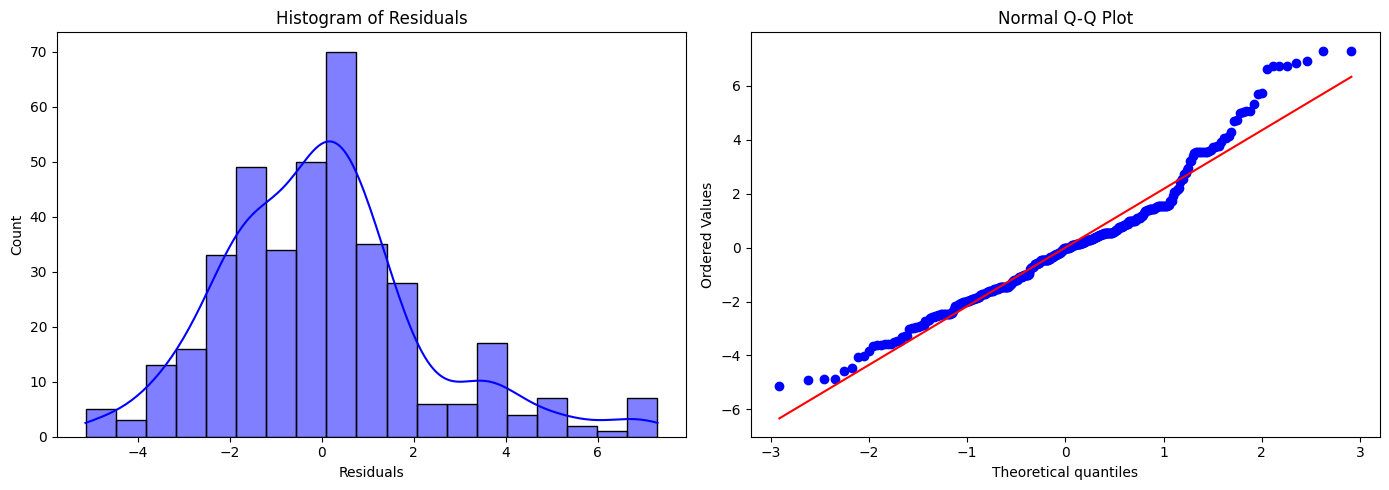

===== UJI NORMALITAS (SHAPIRO-WILK) =====
Statistik Uji : 0.9592
p-value       : 0.0000
Kesimpulan    : Residual TIDAK Berdistribusi Normal (Tolak H0)


In [29]:
import scipy.stats as stats

# Setup plot 1 baris, 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram Residual
sns.histplot(residuals, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residuals')

# 2. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

# 3. Uji Formal Shapiro-Wilk
stat, p_value = stats.shapiro(residuals)
print("===== UJI NORMALITAS (SHAPIRO-WILK) =====")
print(f"Statistik Uji : {stat:.4f}")
print(f"p-value       : {p_value:.4f}")
if p_value > 0.05:
    print("Kesimpulan    : Residual Berdistribusi Normal (Gagal Tolak H0)")
else:
    print("Kesimpulan    : Residual TIDAK Berdistribusi Normal (Tolak H0)")

### Multikolinearitas

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                Feature          VIF
0  Mean_Yankee Pressure  8284.971847
1          Mean_Creping   154.592905
2                % NBKP   111.906422
3   Mean_Jet Wire Ratio  6330.100173
4                   GSM   328.382007
